# 🎬 Sentiment Analysis on IMDb Movie Reviews
---
**Task 1 – NLP Assignment**

This notebook performs end-to-end sentiment analysis on the IMDb movie-review dataset:
1. Data loading & exploration
2. Text cleaning & preprocessing (HTML, URLs, emojis, negations, stop-words, lemmatisation)
3. Feature engineering (TF-IDF & CountVectorizer)
4. Model training & comparison (Logistic Regression, Naïve Bayes, SVM, Random Forest, Gradient Boosting)
5. Evaluation (Accuracy, F1, ROC-AUC, Confusion Matrix)
6. Visualisation (Word Clouds, Feature Importance, ROC curves)
7. Deployment simulation (predict function + model saving)

## 1 · Imports & Setup

In [1]:
import warnings, re, os, pickle, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                            classification_report, confusion_matrix, roc_curve)
from sklearn.calibration import CalibratedClassifierCV


sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
print("✅ All imports successful")

✅ All imports successful


## 2 · Load the IMDb Dataset

In [2]:
# Load the local IMDB Dataset CSV
df = pd.read_csv("IMDB Dataset.csv")

# Map text labels to numeric: positive -> 1, negative -> 0
df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})

print(f"✅ Loaded IMDb dataset from local CSV: {len(df)} reviews")
df.head()

✅ Loaded IMDb dataset from local CSV: 50000 reviews


,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


## 3 · Exploratory Data Analysis

In [3]:
print(f"Shape : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
print(f"Dtypes :\n{df.dtypes}")
print(f"\nNull counts:\n{df.isnull().sum()}")
print(f"\nDuplicates: {df.duplicated().sum()}")
print(f"\nSentiment distribution:\n{df['sentiment'].value_counts()}")

Shape : (50000, 2)
Columns : ['review', 'sentiment']
Dtypes :
review       object
sentiment     int64
dtype: object

Null counts:
review       0
sentiment    0
dtype: int64

Duplicates: 418

Sentiment distribution:
sentiment
1    25000
0    25000
Name: count, dtype: int64


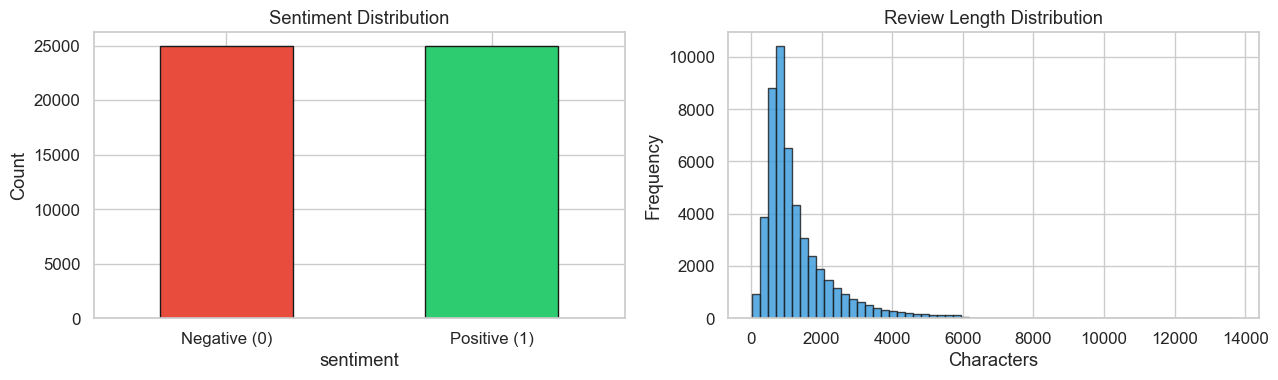

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sentiment distribution
df["sentiment"].value_counts().plot.bar(ax=axes[0], color=["#e74c3c","#2ecc71"], edgecolor="k")
axes[0].set_title("Sentiment Distribution")
axes[0].set_xticklabels(["Negative (0)", "Positive (1)"], rotation=0)
axes[0].set_ylabel("Count")

# Review length distribution
df["review_len"] = df["review"].str.len()
df["review_len"].hist(bins=60, ax=axes[1], color="#3498db", edgecolor="k", alpha=0.8)
axes[1].set_title("Review Length Distribution")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 4 · Text Cleaning & Preprocessing
We handle every requirement from the task:
- Remove HTML tags & URLs
- Convert emojis to sentiment tokens
- Handle negations ("not good" → "not_good")
- Lowercase, remove punctuation/numbers
- Remove stop-words
- Lemmatisation (preferred over stemming)
- Remove duplicates & very short reviews

In [7]:
# ---------- emoji mapping ----------
EMOJI_SENTIMENT = {
    "😀": "happy", "😃": "happy", "😄": "happy", "😁": "happy",
    "😆": "happy", "🤣": "happy", "😂": "happy", "🙂": "happy",
    "😊": "happy", "😍": "love", "🥰": "love", "😘": "love",
    "❤️": "love", "💕": "love", "👍": "good", "👏": "good",
    "🔥": "great", "💯": "perfect", "🎉": "celebration",
    "😢": "sad", "😭": "sad", "😞": "sad", "😔": "sad",
    "😠": "angry", "😡": "angry", "🤮": "disgusting",
    "👎": "bad", "💔": "heartbreak", "😒": "annoyed",
    "🙄": "annoyed", "😤": "frustrated",
}

NEGATION_WORDS = {"not", "no", "never", "neither", "nobody", "nothing",
                    "nowhere", "nor", "cannot", "can't", "won't", "don't",
                    "doesn't", "didn't", "isn't", "aren't", "wasn't", "weren't",
                    "wouldn't", "shouldn't", "couldn't", "hasn't", "haven't",
                    "hadn't", "mustn't"}

STOP_WORDS = set(stopwords.words("english")) - NEGATION_WORDS  # keep negation words!
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """Full preprocessing pipeline."""
    # 1. Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)
    # 2. Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    # 3. Convert emojis to tokens
    for emoji, token in EMOJI_SENTIMENT.items():
        text = text.replace(emoji, f" {token} ")
    # 4. Lowercase
    text = text.lower()
    # 5. Handle contractions for negation
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'s", "", text)
    # 6. Handle negations – attach next word
    text = re.sub(r"\b(not|no|never)\s+(\w+)", r"\1_\2", text)
    # 7. Remove non-alpha (keep underscores for negation tokens)
    text = re.sub(r"[^a-z_\s]", " ", text)
    # 8. Tokenize
    tokens = text.split()
    # 9. Remove stop-words & lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return " ".join(tokens)

# Test
sample = "This movie is <b>NOT</b> good 😡! Visited http://bad.com for more."
print("Before:", sample)
print("After :", clean_text(sample))

Before: This movie is <b>NOT</b> good 😡! Visited http://bad.com for more.
After : movie not_good angry visited


In [7]:
# Apply cleaning
print("⏳ Cleaning all reviews …")
df["clean_review"] = df["review"].apply(clean_text)

# Remove duplicates
before = len(df)
df.drop_duplicates(subset="clean_review", inplace=True)
print(f"   Removed {before - len(df)} duplicates")

# Remove very short reviews (< 20 chars after cleaning)
before = len(df)
df = df[df["clean_review"].str.len() >= 20].reset_index(drop=True)
print(f"   Removed {before - len(df)} very-short reviews")
print(f"✅ Final dataset: {len(df)} reviews")
df[["review", "clean_review"]].head()

⏳ Cleaning all reviews …
   Removed 426 duplicates
   Removed 1 very-short reviews
✅ Final dataset: 49573 reviews


,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


## 5 · Feature Engineering – TF-IDF & CountVectorizer

In [8]:
X = df["clean_review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 39658 | Test size: 9915


In [9]:
# TF-IDF (primary)
tfidf = TfidfVectorizer(max_features=30_000, ngram_range=(1, 2), min_df=3, max_df=0.95)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# CountVectorizer (for comparison / Naïve Bayes)
count_vec = CountVectorizer(max_features=30_000, ngram_range=(1, 2), min_df=3, max_df=0.95)
X_train_cv = count_vec.fit_transform(X_train)
X_test_cv  = count_vec.transform(X_test)

print(f"TF-IDF  feature matrix : {X_train_tfidf.shape}")
print(f"CountVec feature matrix: {X_train_cv.shape}")

TF-IDF  feature matrix : (39658, 30000)
CountVec feature matrix: (39658, 30000)


## 6 · Model Training & Comparison
### Baseline Models
- Logistic Regression
- Multinomial Naïve Bayes
- Support Vector Machine (LinearSVC)

### Advanced Models
- Random Forest
- Gradient Boosting

In [10]:
results = []

def train_eval(name, model, X_tr, X_te, needs_proba=True):
    """Train, predict, evaluate, and store results."""
    t0 = time.time()
    model.fit(X_tr, y_train)
    elapsed = time.time() - t0
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    # ROC-AUC needs probability scores
    if needs_proba and hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_te)
        auc = roc_auc_score(y_test, y_scores)
        y_proba = y_scores  # for ROC curve
    else:
        auc = None
        y_proba = None

    results.append({
        "Model": name, "Accuracy": acc, "F1": f1,
        "ROC-AUC": auc, "Time (s)": round(elapsed, 2),
        "y_pred": y_pred, "y_proba": y_proba
    })
    print(f"  {name:30s} | Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f} | {elapsed:.1f}s")
    return model

In [11]:
print("=" * 75)
print("BASELINE MODELS")
print("=" * 75)

lr_model = train_eval(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    X_train_tfidf, X_test_tfidf
)

nb_model = train_eval(
    "Multinomial Naïve Bayes",
    MultinomialNB(alpha=1.0),
    X_train_cv, X_test_cv    # CountVec works better for NB
)

svm_base = LinearSVC(max_iter=2000, C=1.0, random_state=42)
svm_cal  = CalibratedClassifierCV(svm_base, cv=3)
svm_model = train_eval(
    "SVM (LinearSVC + Calibration)",
    svm_cal,
    X_train_tfidf, X_test_tfidf
)

print()
print("=" * 75)
print("ADVANCED MODELS")
print("=" * 75)

rf_model = train_eval(
    "Random Forest",
    RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1),
    X_train_tfidf, X_test_tfidf
)

gb_model = train_eval(
    "Gradient Boosting",
    GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42),
    X_train_tfidf, X_test_tfidf
)

BASELINE MODELS
  Logistic Regression            | Acc=0.9010 | F1=0.9021 | AUC=0.9662 | 0.9s
  Multinomial Naïve Bayes        | Acc=0.8722 | F1=0.8720 | AUC=0.9366 | 0.0s
  SVM (LinearSVC + Calibration)  | Acc=0.9062 | F1=0.9070 | AUC=0.9680 | 1.7s

ADVANCED MODELS
  Random Forest                  | Acc=0.8683 | F1=0.8690 | AUC=0.9408 | 36.6s
  Gradient Boosting              | Acc=0.8520 | F1=0.8567 | AUC=0.9343 | 449.0s


## 7 · Model Evaluation

### 7.1 · Model Comparison Report

In [12]:
report_df = pd.DataFrame(results)[["Model", "Accuracy", "F1", "ROC-AUC", "Time (s)"]]
report_df = report_df.sort_values("F1", ascending=False).reset_index(drop=True)
report_df.style.format({
    "Accuracy": "{:.4f}", "F1": "{:.4f}", "ROC-AUC": "{:.4f}"
}).background_gradient(cmap="Greens", subset=["Accuracy", "F1", "ROC-AUC"])

,Model,Accuracy,F1,ROC-AUC,Time (s)
0,SVM (LinearSVC + Calibration),0.9062,0.9070,0.9680,1.670000
1,Logistic Regression,0.9010,0.9021,0.9662,0.940000
2,Multinomial Naïve Bayes,0.8722,0.8720,0.9366,0.020000
3,Random Forest,0.8683,0.8690,0.9408,36.590000
4,Gradient Boosting,0.8520,0.8567,0.9343,448.980000


### 7.2 · Detailed Classification Reports

In [13]:
for r in results:
    print(f"\n{'─'*60}")
    print(f"  {r['Model']}")
    print(f"{'─'*60}")
    print(classification_report(y_test, r["y_pred"], target_names=["Negative","Positive"]))


────────────────────────────────────────────────────────────
  Logistic Regression
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      4939
    Positive       0.89      0.91      0.90      4976

    accuracy                           0.90      9915
   macro avg       0.90      0.90      0.90      9915
weighted avg       0.90      0.90      0.90      9915


────────────────────────────────────────────────────────────
  Multinomial Naïve Bayes
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.87      0.88      0.87      4939
    Positive       0.88      0.87      0.87      4976

    accuracy                           0.87      9915
   macro avg       0.87      0.87      0.87      9915
weighted avg       0.87      0.87      0.87      9915


───────────────────────────────────────────────────

### 7.3 · Confusion Matrix Heatmaps

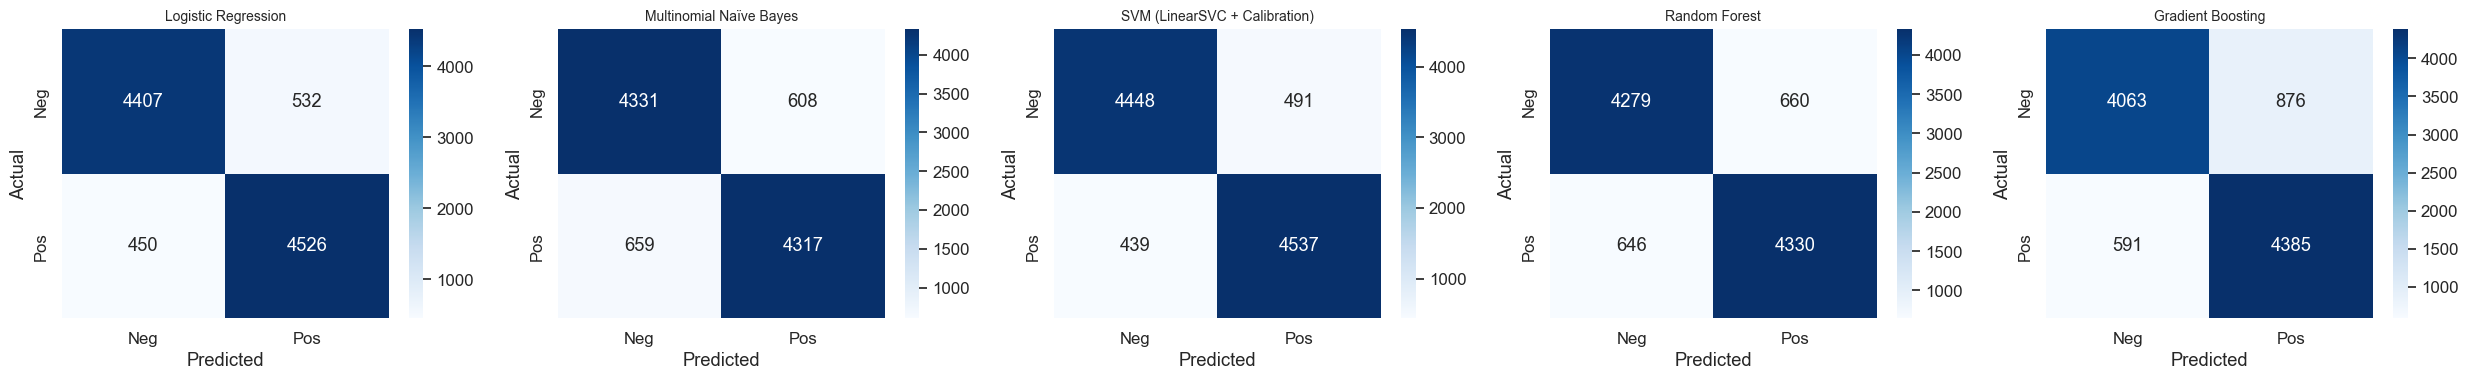

In [14]:
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    cm = confusion_matrix(y_test, r["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Neg","Pos"], yticklabels=["Neg","Pos"])
    ax.set_title(r["Model"], fontsize=10)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.show()

### 7.4 · ROC-AUC Curves

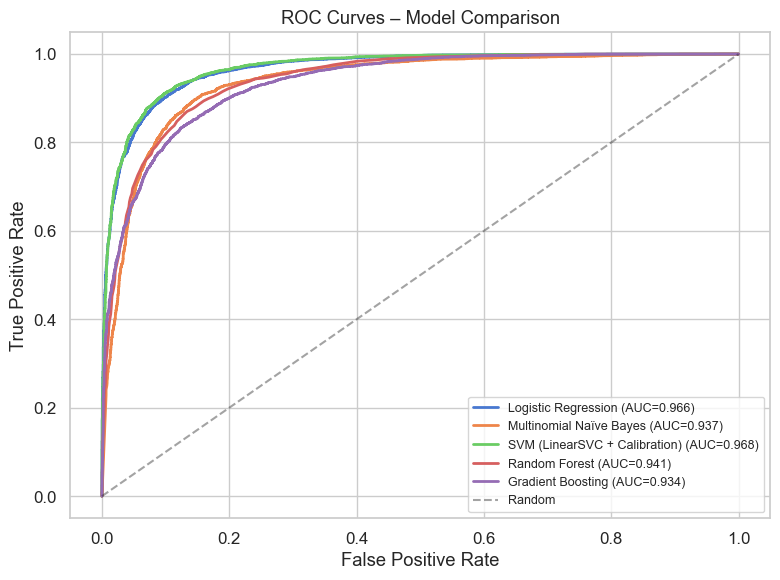

In [15]:
plt.figure(figsize=(8, 6))
for r in results:
    if r["y_proba"] is not None:
        fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
        plt.plot(fpr, tpr, label=f"{r['Model']} (AUC={r['ROC-AUC']:.3f})", linewidth=2)

plt.plot([0,1], [0,1], "k--", alpha=0.4, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Model Comparison")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## 8 · Visualisations

### 8.1 · Word Clouds – Positive vs Negative

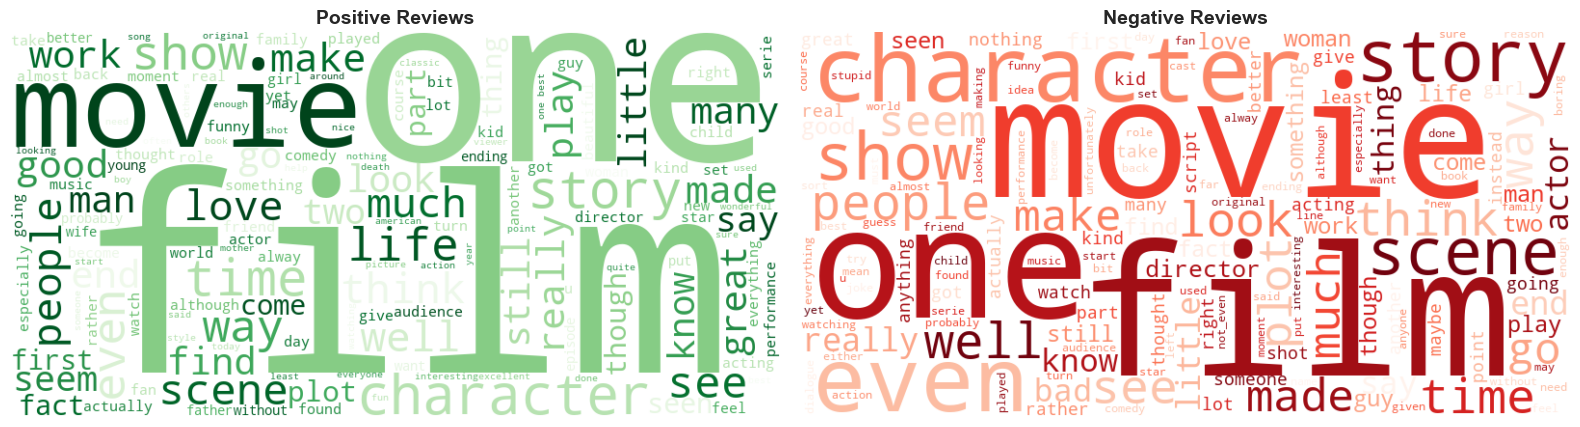

In [16]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (label, name, cmap) in zip(axes, [(1, "Positive", "Greens"), (0, "Negative", "Reds")]):
    text = " ".join(df[df["sentiment"] == label]["clean_review"])
    wc = WordCloud(width=800, height=400, background_color="white",
                    colormap=cmap, max_words=150).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{name} Reviews", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### 8.2 · Top TF-IDF Features (Logistic Regression Coefficients)

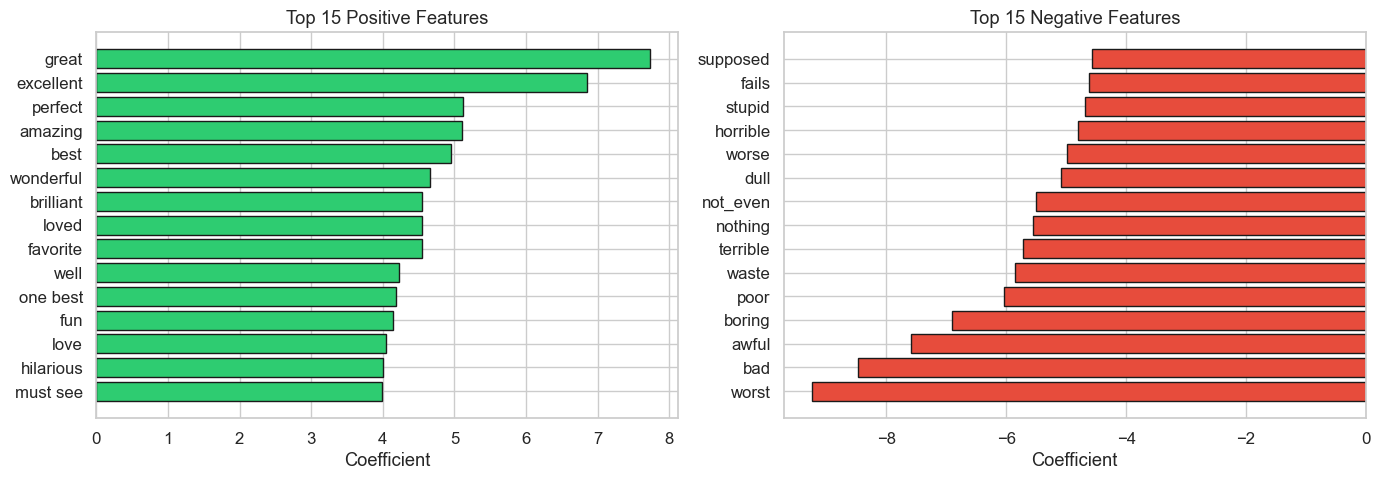

In [17]:
# Use the Logistic Regression coefficients to find most important features
lr = results[0]  # first model is LR
lr_model_obj = lr_model  # the fitted model

feature_names = tfidf.get_feature_names_out()
coefs = lr_model_obj.coef_[0]

top_pos_idx = np.argsort(coefs)[-15:]
top_neg_idx = np.argsort(coefs)[:15]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top positive
axes[0].barh(range(15), coefs[top_pos_idx], color="#2ecc71", edgecolor="k")
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(feature_names[top_pos_idx])
axes[0].set_title("Top 15 Positive Features")
axes[0].set_xlabel("Coefficient")

# Top negative
axes[1].barh(range(15), coefs[top_neg_idx], color="#e74c3c", edgecolor="k")
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(feature_names[top_neg_idx])
axes[1].set_title("Top 15 Negative Features")
axes[1].set_xlabel("Coefficient")

plt.tight_layout()
plt.show()

### 8.3 · Accuracy & F1 Bar Chart Comparison

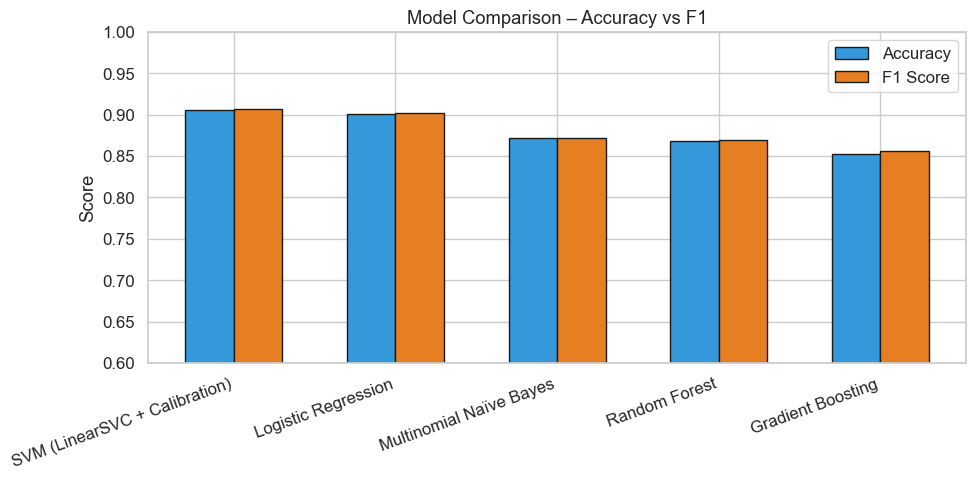

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(report_df))
w = 0.3

ax.bar(x - w/2, report_df["Accuracy"], w, label="Accuracy", color="#3498db", edgecolor="k")
ax.bar(x + w/2, report_df["F1"],       w, label="F1 Score", color="#e67e22", edgecolor="k")
ax.set_xticks(x)
ax.set_xticklabels(report_df["Model"], rotation=20, ha="right")
ax.set_ylim(0.6, 1.0)
ax.set_ylabel("Score")
ax.set_title("Model Comparison – Accuracy vs F1")
ax.legend()
plt.tight_layout()
plt.show()

## 9 · Insights & Discussion

### Why do some models perform better?
- **Logistic Regression & SVM** excel on high-dimensional sparse text data (TF-IDF). They find linear decision boundaries efficiently.
- **Naïve Bayes** is fast and works well with count features, but its strong independence assumption limits performance on nuanced reviews.
- **Random Forest / Gradient Boosting** are powerful ensemble methods, but tree-based models can struggle with very high-dimensional sparse features compared to linear models.

### Trade-offs
| Aspect | Linear Models (LR, SVM) | Tree Ensembles (RF, GB) | Naïve Bayes |
|--------|------------------------|------------------------|-------------|
| **Speed** | Fast | Slow (especially GB) | Very fast |
| **Accuracy** | High | Moderate-High | Moderate |
| **Interpretability** | High (coefficients) | Low | Moderate |
| **Handles sparse data** | Excellent | Moderate | Good |

### Key Takeaway
For text classification tasks with TF-IDF features, **linear models** (Logistic Regression, SVM) tend to be the best choice — they are fast, accurate, and interpretable.

## 10 · Deployment Simulation

In [19]:
# Save the best model (Logistic Regression) and the TF-IDF vectorizer
MODEL_DIR = os.path.join(os.path.dirname(os.path.abspath(".")), "saved_model")
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, "sentiment_model.pkl")
vec_path   = os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl")

with open(model_path, "wb") as f:
    pickle.dump(lr_model, f)
with open(vec_path, "wb") as f:
    pickle.dump(tfidf, f)

print(f"✅ Model saved to {model_path}")
print(f"✅ Vectorizer saved to {vec_path}")

✅ Model saved to c:\Users\Lenovo\Desktop\DEPI(R_2)\ML_git\GIZ4_AIS2_S1_Ml\src\NLP\Session_2\saved_model\sentiment_model.pkl
✅ Vectorizer saved to c:\Users\Lenovo\Desktop\DEPI(R_2)\ML_git\GIZ4_AIS2_S1_Ml\src\NLP\Session_2\saved_model\tfidf_vectorizer.pkl


In [20]:
def predict_review(text: str) -> str:
    """Predict sentiment of a single review."""
    cleaned = clean_text(text)
    features = tfidf.transform([cleaned])
    pred = lr_model.predict(features)[0]
    proba = lr_model.predict_proba(features)[0]
    label = "Positive 😊" if pred == 1 else "Negative 😞"
    confidence = proba[pred] * 100
    return f"{label} (confidence: {confidence:.1f}%)"

# ── Test predictions ──
test_reviews = [
    "This product is absolutely amazing! Best purchase ever!",
    "Terrible quality. Broke after one day. Total waste of money.",
    "It's okay, not great but not bad either. Does the job.",
    "I love this movie so much, the acting was phenomenal!",
    "Worst experience of my life. Do NOT buy this.",
]

print("=" * 60)
print("  SENTIMENT PREDICTION DEMO")
print("=" * 60)
for rev in test_reviews:
    print(f"\n📝 \"{rev}\"")
    print(f"   → {predict_review(rev)}")

  SENTIMENT PREDICTION DEMO

📝 "This product is absolutely amazing! Best purchase ever!"
   → Positive 😊 (confidence: 92.9%)

📝 "Terrible quality. Broke after one day. Total waste of money."
   → Negative 😞 (confidence: 98.7%)

📝 "It's okay, not great but not bad either. Does the job."
   → Negative 😞 (confidence: 82.3%)

📝 "I love this movie so much, the acting was phenomenal!"
   → Positive 😊 (confidence: 80.9%)

📝 "Worst experience of my life. Do NOT buy this."
   → Negative 😞 (confidence: 87.7%)


---
## ✅ Summary

| Step | Status |
|------|--------|
| Data Loading | ✅ |
| EDA | ✅ |
| Text Cleaning (HTML, URLs, Emojis, Negations, Lemmatisation) | ✅ |
| TF-IDF & CountVectorizer | ✅ |
| Baseline Models (LR, NB, SVM) | ✅ |
| Advanced Models (RF, GB) | ✅ |
| Evaluation (Accuracy, F1, ROC-AUC, Confusion Matrix) | ✅ |
| Visualisation (Word Clouds, Feature Importance, ROC Curves) | ✅ |
| Model Comparison Report | ✅ |
| Insights & Discussion | ✅ |
| Deployment Simulation (pickle + predict function) | ✅ |